# Dynamic Capital Structure & Waterfall Analysis

This notebook demonstrates the new dynamic capital structure features in Finstack, including:
1. **Excess Cash Flow (ECF) Sweeps**: Automatically paying down debt with excess cash.
2. **PIK Toggles**: Switching between Cash and PIK interest based on liquidity conditions.
3. **Waterfall Priority**: Defining the order of payments (Fees -> Interest -> Amort -> Sweep -> Equity).

In [6]:
from finstack.core.currency import Currency
from finstack.core.dates.periods import PeriodId
from finstack.core.money import Money
from finstack.statements.builder import ModelBuilder
from finstack.statements.types import AmountOrScalar, EcfSweepSpec, PaymentPriority, PikToggleSpec, WaterfallSpec
from finstack.statements.evaluator import EvaluatorWithContext
from finstack.core.market_data import MarketContext
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt

# Helper to format output
pd.options.display.float_format = '{:,.2f}'.format


## 1. Define the Operating Model

We'll create a simple LBO model with volatile revenue and liquidity to test our dynamic triggers.

In [7]:
builder = ModelBuilder.new("LBO_Dynamic")
builder.periods("2025Q1..2026Q4", None)

# Operating Assumptions
# - Q1 2025: Low liquidity (stress test PIK toggle)
# - Q2 2025: High Revenue (test ECF sweep)
revenue_data = [
    (PeriodId.quarter(2025, 1), AmountOrScalar.scalar(1_000_000.0)),
    (PeriodId.quarter(2025, 2), AmountOrScalar.scalar(2_500_000.0)), # Boom quarter
    (PeriodId.quarter(2025, 3), AmountOrScalar.scalar(1_200_000.0)),
    (PeriodId.quarter(2025, 4), AmountOrScalar.scalar(1_300_000.0)),
    (PeriodId.quarter(2026, 1), AmountOrScalar.scalar(1_400_000.0)),
    (PeriodId.quarter(2026, 2), AmountOrScalar.scalar(1_500_000.0)),
    (PeriodId.quarter(2026, 3), AmountOrScalar.scalar(1_600_000.0)),
    (PeriodId.quarter(2026, 4), AmountOrScalar.scalar(1_700_000.0)),
]

# Liquidity metric for PIK toggle
# Values provided for every period to avoid missing-data errors
liquidity_data = [
    (PeriodId.quarter(2025, 1), AmountOrScalar.scalar(50_000.0)), # Crisis! < 100k threshold
    (PeriodId.quarter(2025, 2), AmountOrScalar.scalar(500_000.0)),
    (PeriodId.quarter(2025, 3), AmountOrScalar.scalar(300_000.0)),
    (PeriodId.quarter(2025, 4), AmountOrScalar.scalar(350_000.0)),
    (PeriodId.quarter(2026, 1), AmountOrScalar.scalar(320_000.0)),
    (PeriodId.quarter(2026, 2), AmountOrScalar.scalar(340_000.0)),
    (PeriodId.quarter(2026, 3), AmountOrScalar.scalar(360_000.0)),
    (PeriodId.quarter(2026, 4), AmountOrScalar.scalar(380_000.0)),
]

builder.value("revenue", revenue_data)
builder.value("liquidity", liquidity_data)

builder.compute("ebitda", "revenue * 0.4") # 40% EBITDA margin
builder.compute("capex", "revenue * 0.05") # 5% Capex
builder.compute("taxes", "ebitda * 0.25")  # 25% Tax rate

## 2. Define Capital Structure & Waterfall

We add a Term Loan with an 8% interest rate. 

**Waterfall Logic:**
- **ECF Sweep**: 75% of (EBITDA - Taxes - Capex) goes to pay down debt.
- **PIK Toggle**: If `liquidity` < 100,000, interest switches to PIK (added to principal).

In [8]:
# Add Term Loan A
# $10M Term Loan at 8% interest
# Note: Pass just the spec part (not the full envelope) for add_custom_debt
# All fields must be present (even if None) due to deny_unknown_fields
term_loan_spec = {
    "id": "TL-A",
    "currency": "USD",
    "notional_limit": {"amount": "10000000", "currency": "USD"},
    "issue": "2024-12-31",
    "maturity": "2030-01-01",
    "rate": {"Fixed": {"rate_bp": 800}},  # 8%
    "pay_freq": {"Months": 3},
    "day_count": "Act360",
    "bdc": "modified_following",
    "calendar_id": None,
    "stub": "None",
    "discount_curve_id": "USD-OIS",
    "credit_curve_id": None,
    "amortization": "None",
    "coupon_type": "Cash",
    "upfront_fee": None,
    "ddtl": {
        "commitment_limit": {"amount": "10000000", "currency": "USD"},
        "availability_start": "2024-12-31",
        "availability_end": "2026-01-01",
        "draws": [
            {
                "date": "2024-12-31",
                "amount": {"amount": "10000000", "currency": "USD"}
            }
        ],
        "commitment_step_downs": [],
        "usage_fee_bp": 0,
        "commitment_fee_bp": 0,
        "fee_base": "Undrawn",
        "oid_policy": None
    },
    "covenants": None,
    "pricing_overrides": {
        "quoted_clean_price": None,
        "rho_bump_decimal": None,
        "vega_bump_decimal": None,
        "implied_volatility": None,
        "quoted_spread_bp": None,
        "upfront_payment": None,
        "ytm_bump_decimal": None,
        "theta_period": None,
        "mc_seed_scenario": None,
        "adaptive_bumps": False,
        "spot_bump_pct": None,
        "vol_bump_pct": None,
        "rate_bump_bp": None
    },
    "call_schedule": None,
    "attributes": {
        "tags": [],
        "meta": {}
    }
}

builder.add_custom_debt("TL-A", term_loan_spec)

# Configure Waterfall
waterfall = WaterfallSpec(
    priority_of_payments=[
        PaymentPriority.Fees,
        PaymentPriority.Interest,
        PaymentPriority.Amortization,
        PaymentPriority.Sweep,
        PaymentPriority.Equity
    ],
    ecf_sweep=EcfSweepSpec(
        ebitda_node="ebitda",
        sweep_percentage=0.75, # Aggressive 75% sweep
        taxes_node="taxes",
        capex_node="capex",
        target_instrument_id="TL-A"
    ),
    pik_toggle=PikToggleSpec(
        liquidity_metric="liquidity",
        threshold=100_000.0,
        target_instrument_ids=["TL-A"]
    )
)

builder.waterfall(waterfall)

# Expose CS metrics
builder.compute("interest_expense", "cs.interest_expense.total")
builder.compute("interest_cash", "cs.interest_expense_cash.total")
builder.compute("interest_pik", "cs.interest_expense_pik.total")
builder.compute("principal_payment", "cs.principal_payment.total")
builder.compute("debt_balance", "cs.debt_balance.total")




## 3. Evaluate & Analyze

We build and evaluate the model, then convert the results to a DataFrame for analysis.

**Note:** Capital structure requires a MarketContext for pricing. We create a simple market context for this example.

In [9]:
model = builder.build()

# Note: Capital structure requires a MarketContext for pricing.
# We create a simple market context for this example.
market_ctx = MarketContext()
evaluator = EvaluatorWithContext.new(market_ctx, date(2025, 1, 1))
results = evaluator.evaluate(model)

# Convert results to DataFrame for easier viewing
data = {
    'Period': [str(p.id) for p in model.periods],
    'EBITDA': [results.get("ebitda", p.id) for p in model.periods],
    'Liquidity': [results.get_or("liquidity", p.id, 0.0) for p in model.periods],
    'Interest (Total)': [results.get("interest_expense", p.id) for p in model.periods],
    'Interest (Cash)': [results.get("interest_cash", p.id) for p in model.periods],
    'Interest (PIK)': [results.get("interest_pik", p.id) for p in model.periods],
    'Principal Sweep': [results.get("principal_payment", p.id) for p in model.periods],
    'Debt Balance': [results.get("debt_balance", p.id) for p in model.periods],
}

df = pd.DataFrame(data)
df.set_index('Period', inplace=True)
df


RuntimeError: Model build error: Failed to deserialize generic debt instrument 'TL-A' as any known type. Tried: Bond, InterestRateSwap, TermLoan, Deposit, ForwardRateAgreement, Repo. The JSON structure must match one of these types exactly.

### Analysis

**Observation 1 (Q1 2025 - PIK Toggle):**
- Liquidity is 50k (< 100k threshold).
- Note that `Interest (Cash)` should be 0 and `Interest (PIK)` should be ~200k (8% / 4 * 10M).
- The Debt Balance increases by the PIK amount.

**Observation 2 (Q2 2025 - ECF Sweep):**
- Revenue jumps to 2.5M, EBITDA is 1.0M.
- ECF = EBITDA (1.0M) - Taxes (250k) - Capex (125k) = 625k.
- Sweep = 75% * 625k = ~468k.
- Principal Sweep should show this amount, reducing the Debt Balance.

In [ ]:
# Verification checks
q1_balance = results.get("debt_balance", PeriodId.quarter(2025, 1))
q2_principal = results.get("principal_payment", PeriodId.quarter(2025, 2))

print("Verification:")
print("-" * 60)
if q1_balance > 10_000_000.0:
    print(f"✅ Q1 PIK Toggle Active: Debt balance increased by ${q1_balance - 10_000_000:.0f} (PIK Interest)")
else:
    print("❌ Q1 PIK Toggle Failed")
    
if q2_principal > 0:
    print(f"✅ Q2 ECF Sweep Active: Sweep payment of ${q2_principal:.0f} applied")
else:
    print("❌ Q2 ECF Sweep Failed")
print("-" * 60)

NameError: name 'df' is not defined

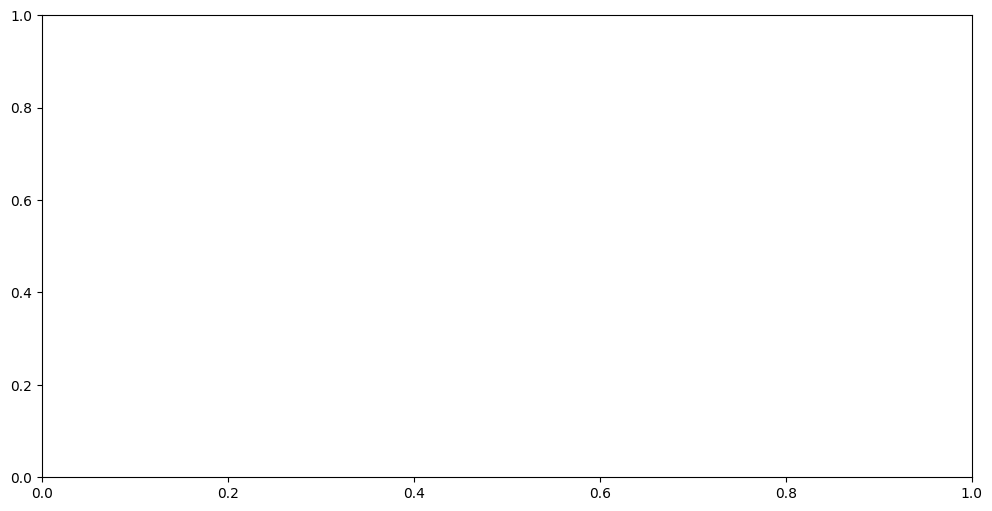

In [ ]:
# Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df.index, df['Debt Balance'], color='navy', alpha=0.6, label='Debt Balance')
ax1.set_ylabel('Debt Balance ($)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_ylim(0, 11_000_000)

ax2 = ax1.twinx()
ax2.plot(df.index, df['Principal Sweep'], color='green', marker='o', linewidth=2, label='Sweep Payment')
ax2.plot(df.index, df['Interest (PIK)'], color='red', marker='x', linewidth=2, label='PIK Interest')
ax2.set_ylabel('Flows ($)', color='black')

plt.title('Capital Structure Dynamics: PIK Toggle & ECF Sweep')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()